# XGBoost Global 5-Minute Forecast

This notebook uses the same core data setup and date split as `07_lgbm_temperature_prediction.ipynb`, but trains one global XGBoost model for the 5-minute forecast.



In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from xgboost_forecast import build_multihorizon_dataset, run_multihorizon_forecast_pipeline


## Configuration

This configuration mirrors notebook 07: the same train/validation/test dates, one 5-minute forecast horizon, and one global model trained with all object labels mixed together.



In [2]:
TEMPERATURE_COLUMN = 'temp_mean_c'
FORECAST_HORIZONS_MIN = [5]
PEOPLE_OR_MACHINE = 'machine'

TRAIN_DATES = ['2025-04-23', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-06', '2025-05-07']
VALID_DATES = ['2025-04-25']
TEST_DATES = ['2025-04-24', '2025-05-02']

VALID_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
GROUP_MODELS = False
GROUP_MODEL_COLUMN = 'canonical_label'

forecast_args = SimpleNamespace(
    input_csv=config.OBJECT_TIMELINE_CSV,
    output_dir=config.XGBOOST_MULTIHORIZON_DIR,
    prediction_csv=config.XGBOOST_MULTIHORIZON_DIR / 'xgboost_5min_predictions.csv',
    metrics_csv=config.XGBOOST_MULTIHORIZON_DIR / 'xgboost_5min_metrics.csv',
    feature_importance_csv=config.XGBOOST_MULTIHORIZON_DIR / 'xgboost_5min_feature_importance.csv',
    learning_curve_png=config.XGBOOST_MULTIHORIZON_DIR / 'xgboost_5min_learning_curve.png',
    temperature_column=TEMPERATURE_COLUMN,
    forecast_horizons_min=FORECAST_HORIZONS_MIN,
    people_or_machine=PEOPLE_OR_MACHINE,
    train_dates=TRAIN_DATES,
    valid_dates=VALID_DATES,
    test_dates=TEST_DATES,
    valid_ratio=VALID_RATIO,
    test_ratio=TEST_RATIO,
    group_models=GROUP_MODELS,
    group_model_column=GROUP_MODEL_COLUMN,
    random_state=RANDOM_STATE,
)


## Build Feature Preview


In [3]:
model_df, feature_columns = build_multihorizon_dataset(
    timeline_csv=forecast_args.input_csv,
    temperature_column=forecast_args.temperature_column,
    forecast_horizons_min=forecast_args.forecast_horizons_min,
    people_or_machine=forecast_args.people_or_machine,
)

{
    'rows': len(model_df),
    'objects': model_df['object_id'].nunique(),
    'source_start': str(model_df['timestamp_dt'].min()),
    'source_end': str(model_df['timestamp_dt'].max()),
    'target_start': str(model_df['target_timestamp'].min()),
    'target_end': str(model_df['target_timestamp'].max()),
    'horizons_requested': FORECAST_HORIZONS_MIN,
    'actual_minutes_ahead_summary': model_df['target_minutes_ahead'].describe(),
    'feature_count': len(feature_columns),
    'features': feature_columns,
    'group_models': forecast_args.group_models,
    'group_model_column': forecast_args.group_model_column,
}




{'rows': 55249,
 'objects': 14,
 'source_start': '2025-04-23 13:43:32',
 'source_end': '2025-05-07 15:12:46',
 'target_start': '2025-04-23 13:48:32',
 'target_end': '2025-05-07 15:17:46',
 'horizons_requested': [5],
 'actual_minutes_ahead_summary': count    55249.000000
 mean         5.154980
 std          0.344131
 min          5.000000
 25%          5.000000
 50%          5.000000
 75%          5.016667
 max          7.500000
 Name: target_minutes_ahead, dtype: float64,
 'feature_count': 61,
 'features': ['object_id',
  'canonical_label',
  'display_x',
  'display_y',
  'anchor_x',
  'anchor_y',
  'hour',
  'minute',
  'day_of_week',
  'source_temp',
  'people_count_total',
  'people_count_within_1m',
  'people_count_within_2m',
  'people_count_within_3m',
  'nearest_person_distance',
  'mean_person_distance',
  'nearest_person_dx',
  'nearest_person_dy',
  'temp_lag_1',
  'temp_lag_2',
  'temp_lag_3',
  'temp_lag_4',
  'temp_lag_5',
  'temp_lag_6',
  'temp_lag_7',
  'temp_lag_8',
  

In [4]:
model_df[['object_id', 'canonical_label', 'timestamp', 'target_timestamp', 'requested_horizon_min', 'target_minutes_ahead', 'temp_mean_c', 'target_temp']].head(20)


,object_id,canonical_label,timestamp,target_timestamp,requested_horizon_min,target_minutes_ahead,temp_mean_c,target_temp
0,cableduct_1,Cableduct,2025-04-23 13:44:33,2025-04-23 13:50:02,5.0,5.483333,21.039400,21.212208
1,cableduct_1,Cableduct,2025-04-23 13:45:02,2025-04-23 13:50:02,5.0,5.000000,21.079897,21.212208
2,cableduct_1,Cableduct,2025-04-23 13:45:32,2025-04-23 13:50:33,5.0,5.016667,21.046547,21.297585
3,cableduct_1,Cableduct,2025-04-23 13:46:02,2025-04-23 13:51:02,5.0,5.000000,21.069269,21.293106
4,cableduct_1,Cableduct,2025-04-23 13:46:32,2025-04-23 13:51:32,5.0,5.000000,21.063841,21.204048
5,cableduct_1,Cableduct,2025-04-23 13:47:02,2025-04-23 13:52:02,5.0,5.000000,21.061125,21.134014
6,cableduct_1,Cableduct,2025-04-23 13:47:32,2025-04-23 13:52:32,5.0,5.000000,21.069017,21.148827
7,cableduct_1,Cableduct,2025-04-23 13:48:02,2025-04-23 13:53:02,5.0,5.000000,21.044666,21.107422
8,cableduct_1,Cableduct,2025-04-23 13:48:32,2025-04-23 13:53:32,5.0,5.000000,21.055481,21.089634
9,cableduct_1,Cableduct,2025-04-23 13:49:02,2025-04-23 13:54:03,5.0,5.016667,21.194807,21.058735


## Train 5-Minute Forecast


In [5]:
result = run_multihorizon_forecast_pipeline(forecast_args)
display(result['metrics'])
if 'group_metrics' in result:
    display(result['group_metrics'].query("split == 'test'").sort_values([forecast_args.group_model_column, 'requested_horizon_min']))
if 'skipped_groups' in result and not result['skipped_groups'].empty:
    display(result['skipped_groups'])



,split,requested_horizon_min,rows,mae,rmse,r2,mean_error,ci_width_mean,ci_coverage
0,test,5.0,15350,0.320956,0.433200,0.737563,0.071442,1.421974,0.890684
1,train,5.0,32475,0.287813,0.429222,0.856382,-0.000494,1.350215,0.952733
2,valid,5.0,7424,0.486353,0.626884,0.351045,0.280844,1.377533,0.602775


## Learning Curve


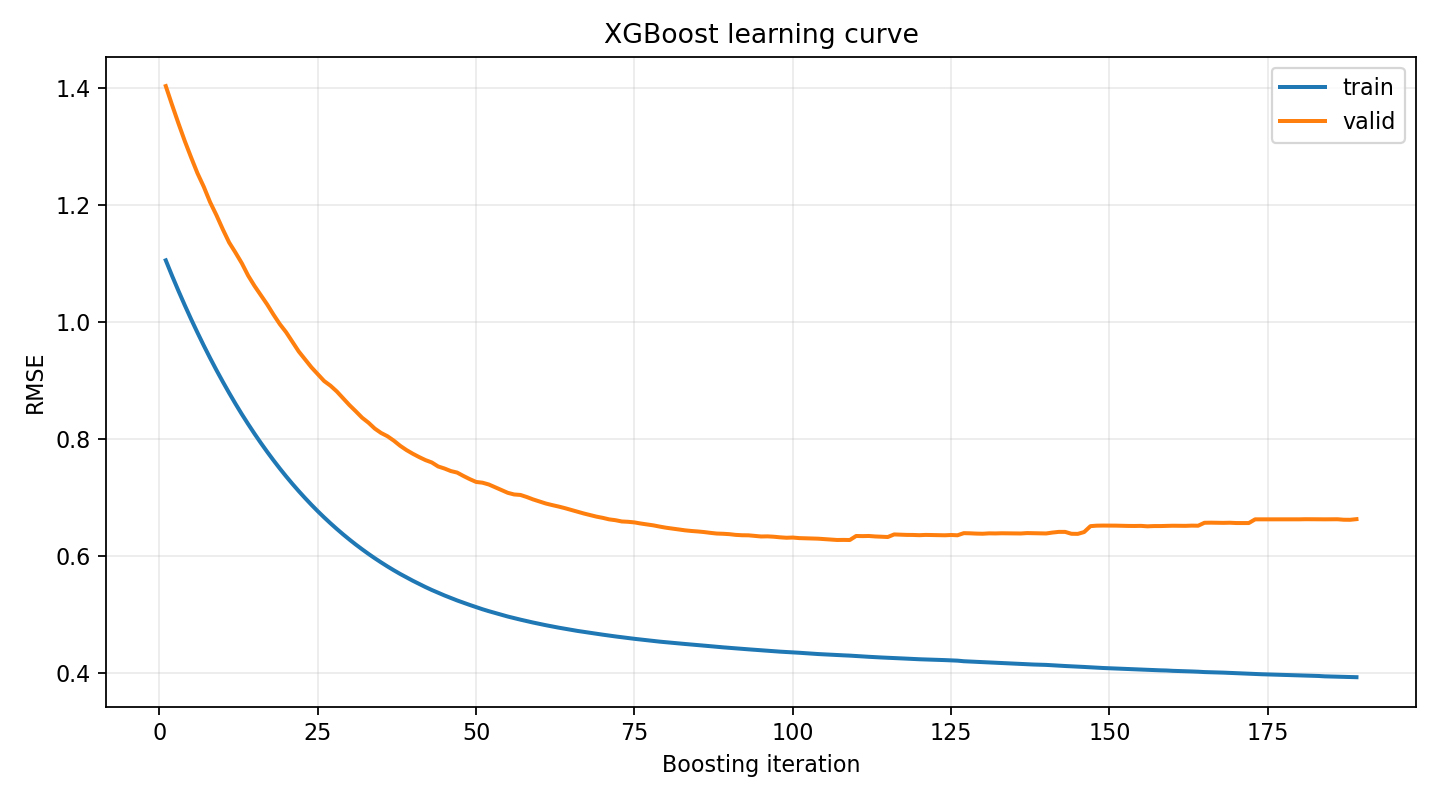

{'train': OrderedDict([('rmse',
               [1.1050745672788833,
                1.0784649680622813,
                1.0529075657040545,
                1.0282759603525409,
                1.0044364997555786,
                0.9815481066221131,
                0.9593510751382515,
                0.9379604245629449,
                0.9173425644212098,
                0.8975598949083755,
                0.8784001106033509,
                0.8599134017392258,
                0.8421429139444604,
                0.825178588372027,
                0.8087570855700834,
                0.7929897129337179,
                0.7778258835048508,
                0.7632497110280786,
                0.7492049412300339,
                0.7357137731010227,
                0.7227783550038311,
                0.710404904023121,
                0.6985084099824096,
                0.6870505886536373,
                0.6760904691255207,
                0.6655784663880202,
                0.6555155740322972

In [6]:
display(Image(filename=str(forecast_args.learning_curve_png)))
result['evals_result']


## Error and CI


,split,requested_horizon_min,rows,mae,rmse,r2,mean_error,ci_width_mean,ci_coverage
0,test,5.0,15350,0.320956,0.4332,0.737563,0.071442,1.421974,0.890684


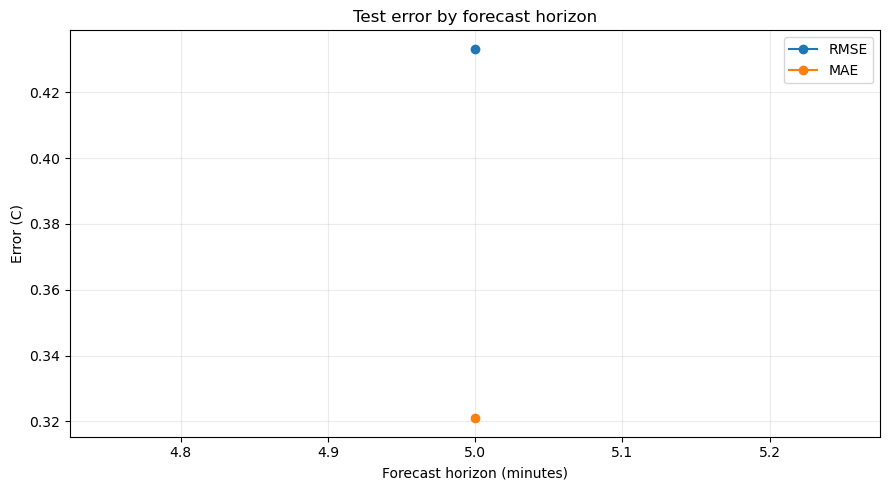

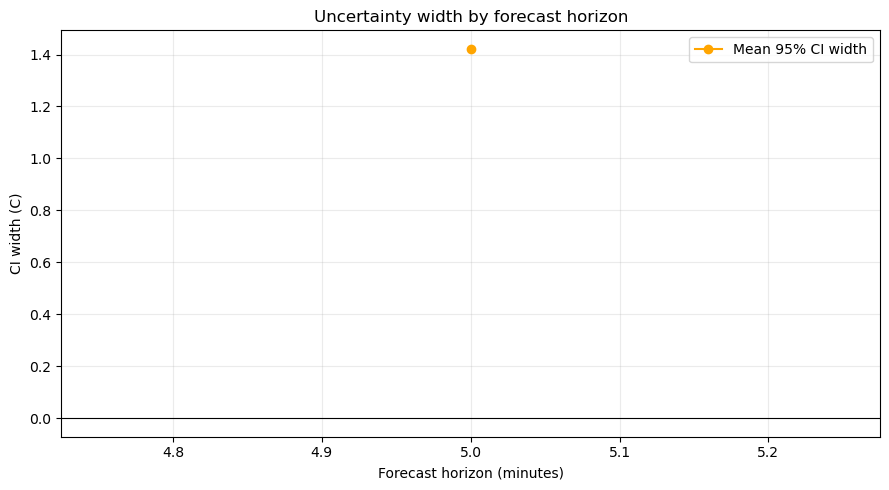

In [7]:
metrics = result['metrics'].copy()
test_metrics = metrics.query("split == 'test'").sort_values('requested_horizon_min')
display(test_metrics)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_metrics['requested_horizon_min'], test_metrics['rmse'], marker='o', label='RMSE')
ax.plot(test_metrics['requested_horizon_min'], test_metrics['mae'], marker='o', label='MAE')
ax.set_xlabel('Forecast horizon (minutes)')
ax.set_ylabel('Error (C)')
ax.set_title('Test error by forecast horizon')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_metrics['requested_horizon_min'], test_metrics['ci_width_mean'], marker='o', color='orange', label='Mean 95% CI width')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Forecast horizon (minutes)')
ax.set_ylabel('CI width (C)')
ax.set_title('Uncertainty width by forecast horizon')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()


## 5-Minute Forecast Curves with 95% CI by Day

This view uses the clean timeline CSV for ground truth and aggregated per-category model predictions for the forecast lines and CI bands.



,object_id,canonical_label,rows,mean_ci_width
7,machine_3,Machine,189,0.936107
8,machine_4,Machine,588,1.048189
11,screen_2,Screen,1491,1.134541
6,machine_2,Machine,1109,1.144632
0,cableduct_1,Cableduct,925,1.340223
2,cableduct_3,Cableduct,1418,1.360009
12,window_1,Window,475,1.368027
9,machine_6,Machine,1240,1.402675
1,cableduct_2,Cableduct,1249,1.491251
3,cableduct_4,Cableduct,1472,1.491330


GT plot rows from timeline: 60,334
Prediction plot rows: 15,350 -> 12,007 after target-time aggregation
Target date: 2025-04-24
Target date: 2025-05-02


/var/folders/r7/6cnjjpl12cl8kc68cxt7dd9w0000gn/T/ipykernel_48361/2246576159.py:101: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(13, 4.8))


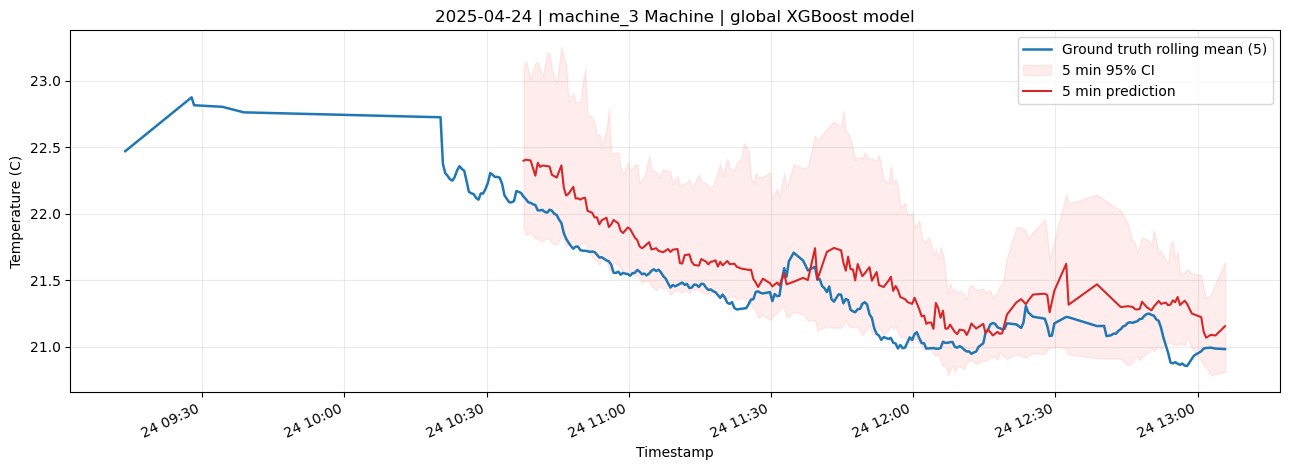

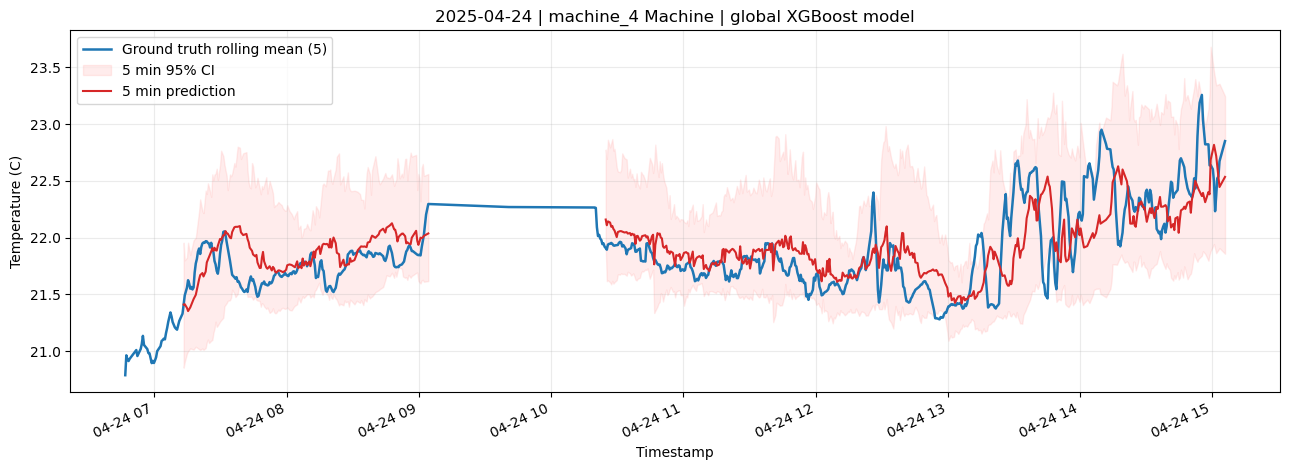

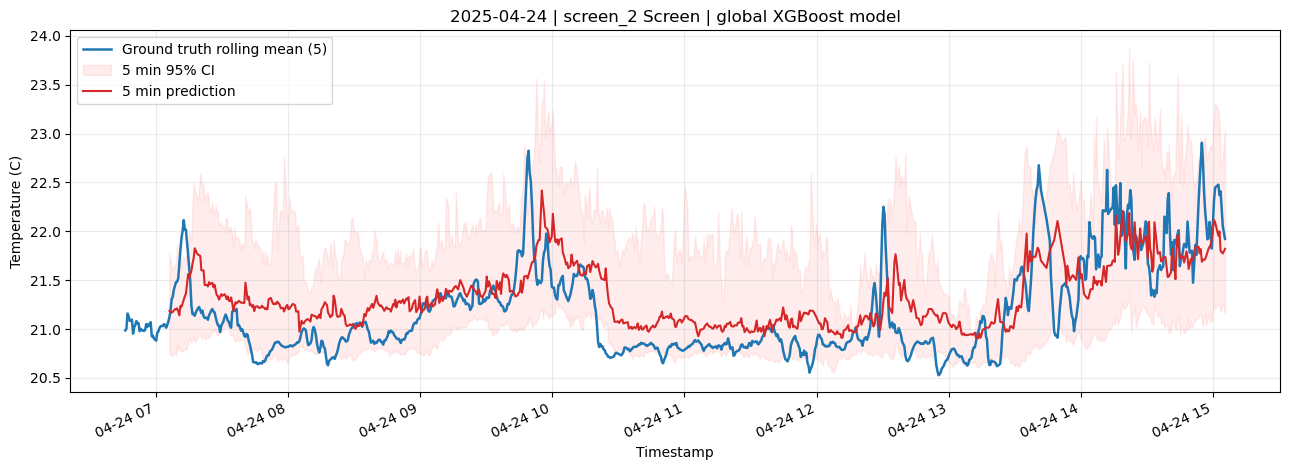

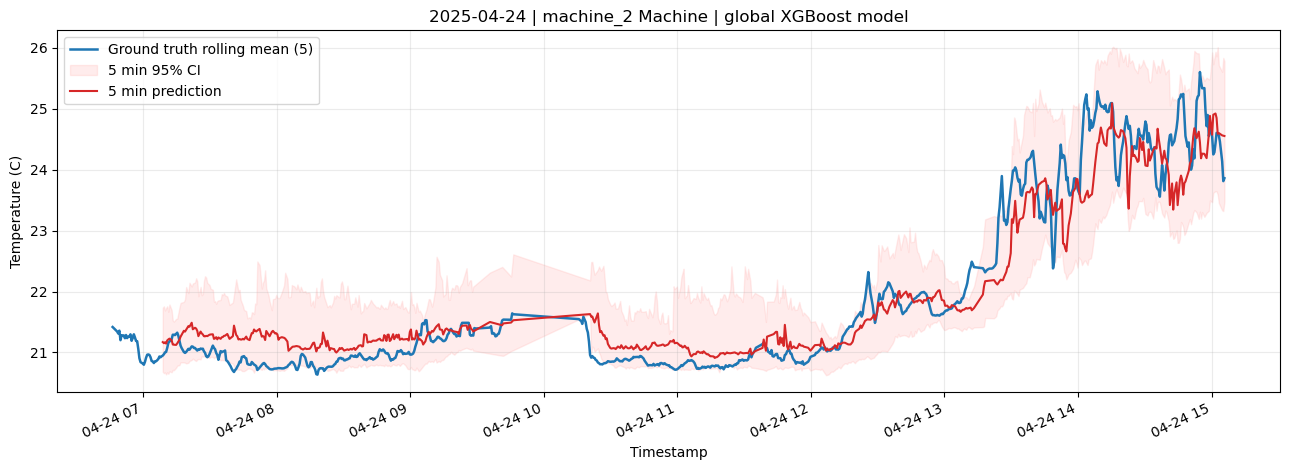

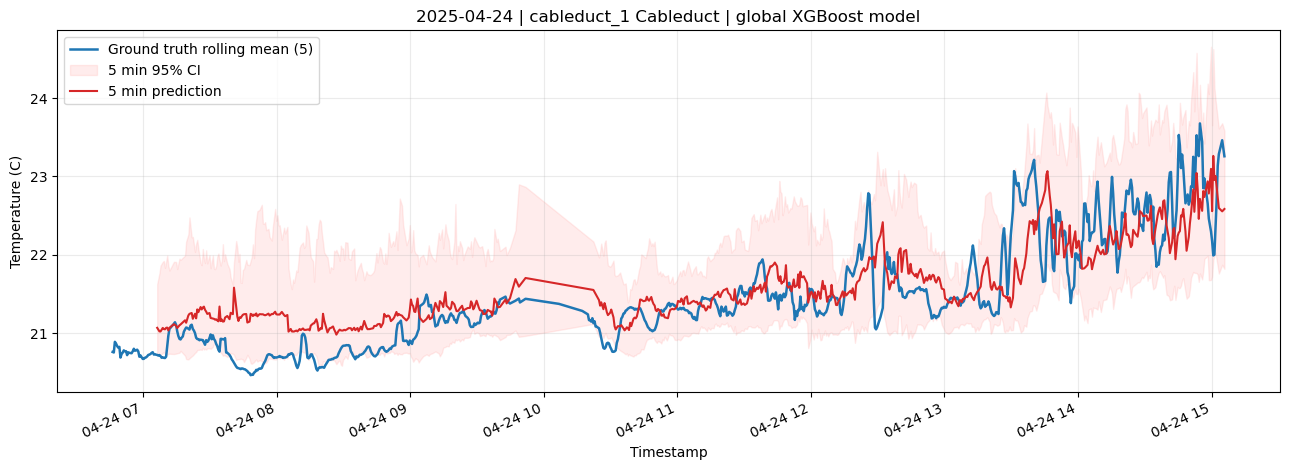

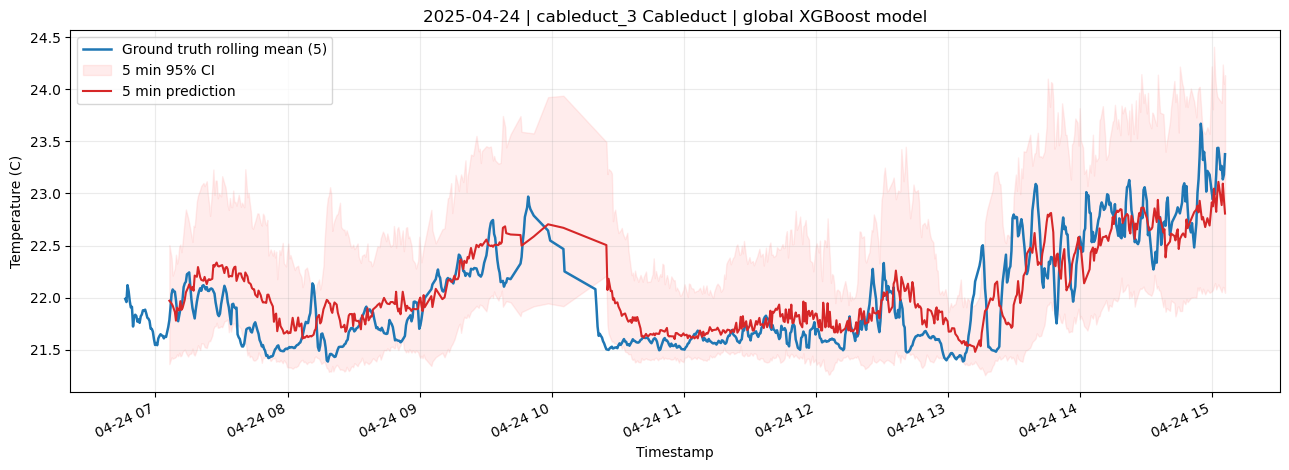

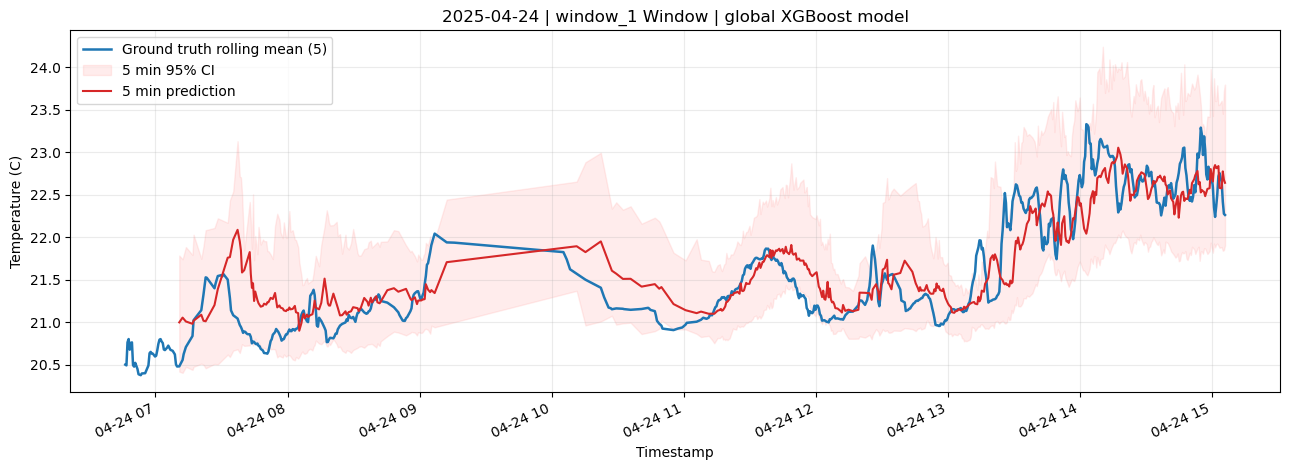

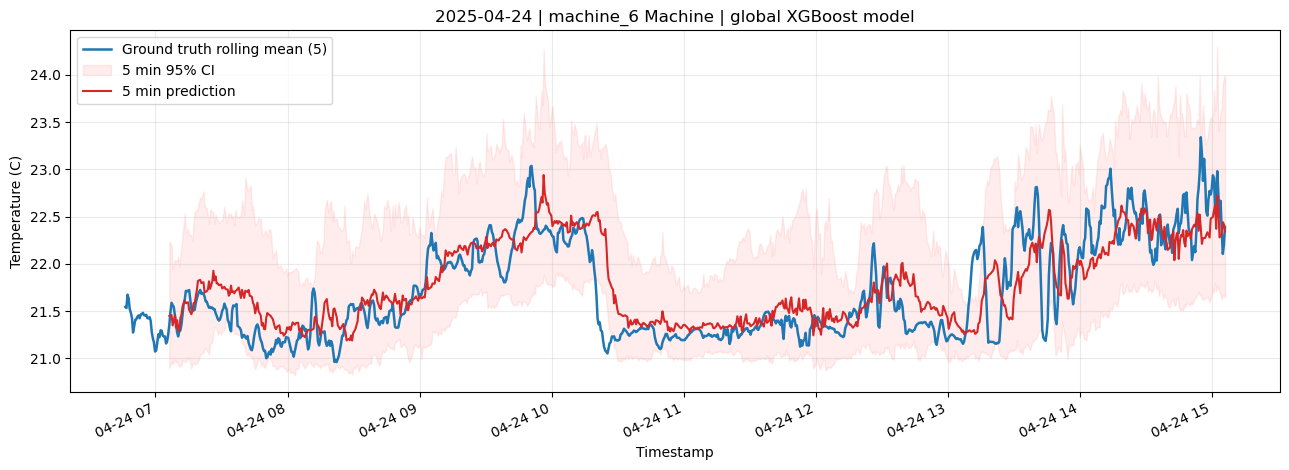

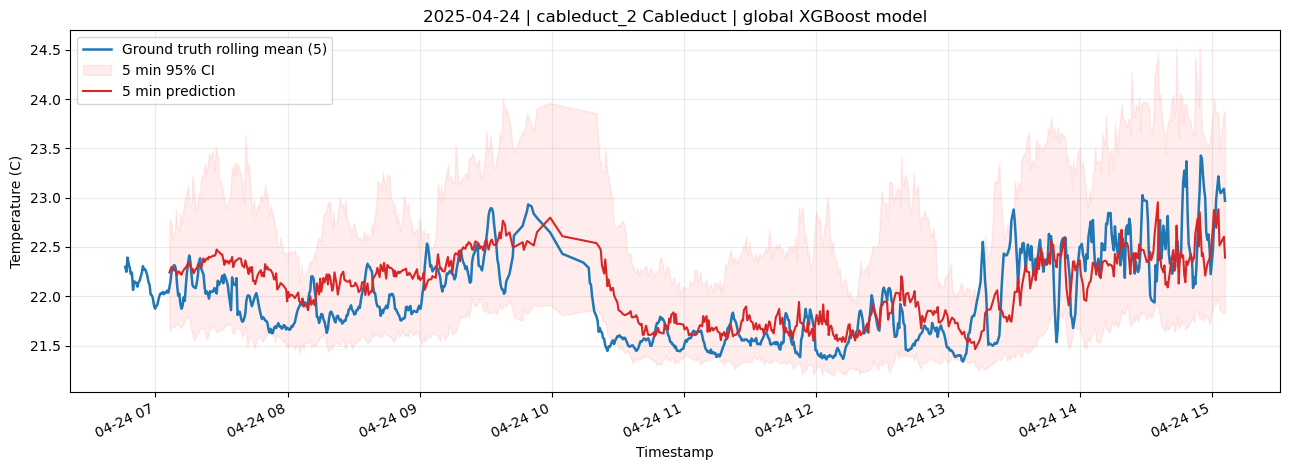

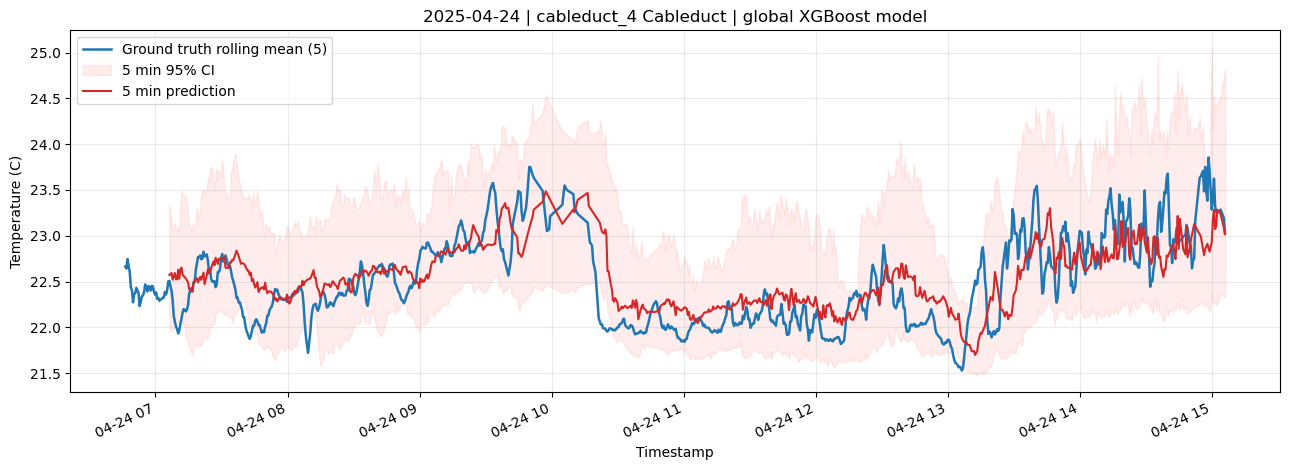

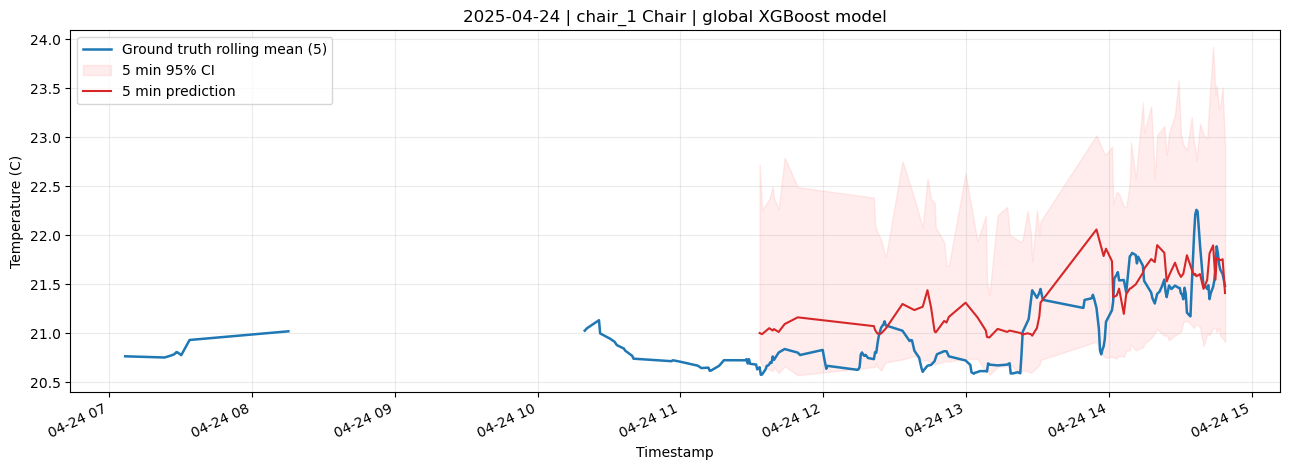

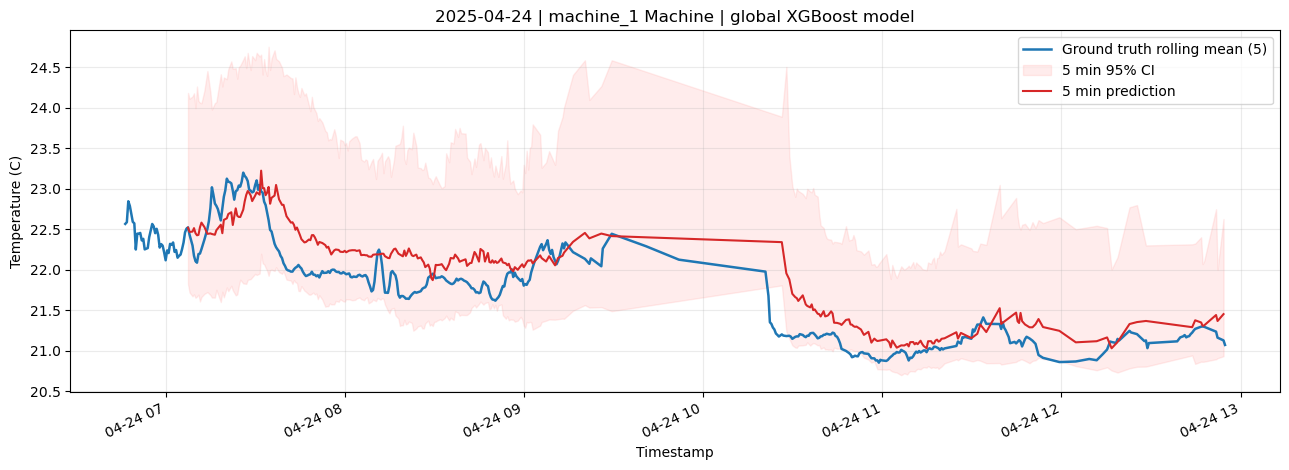

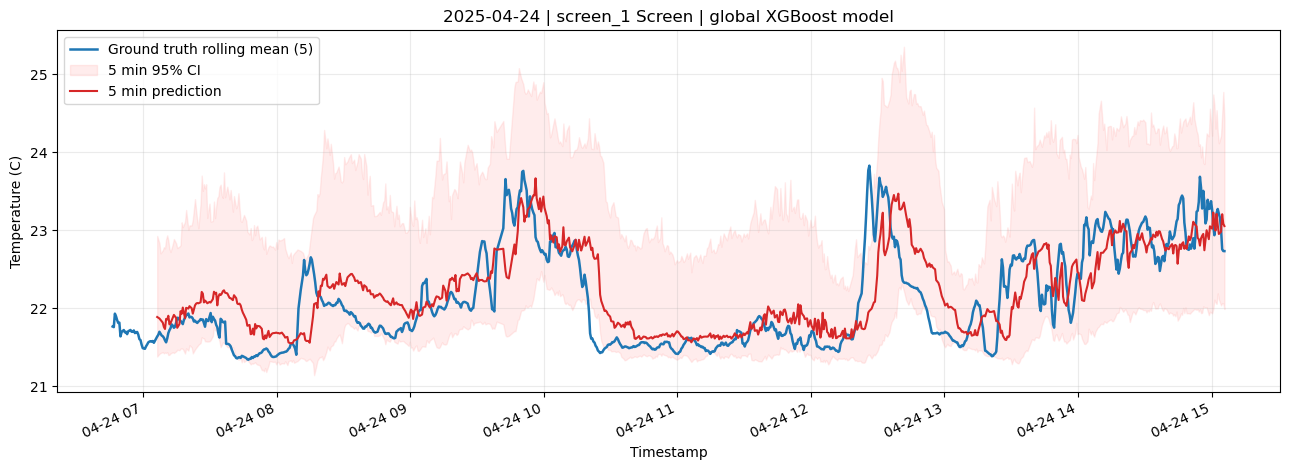

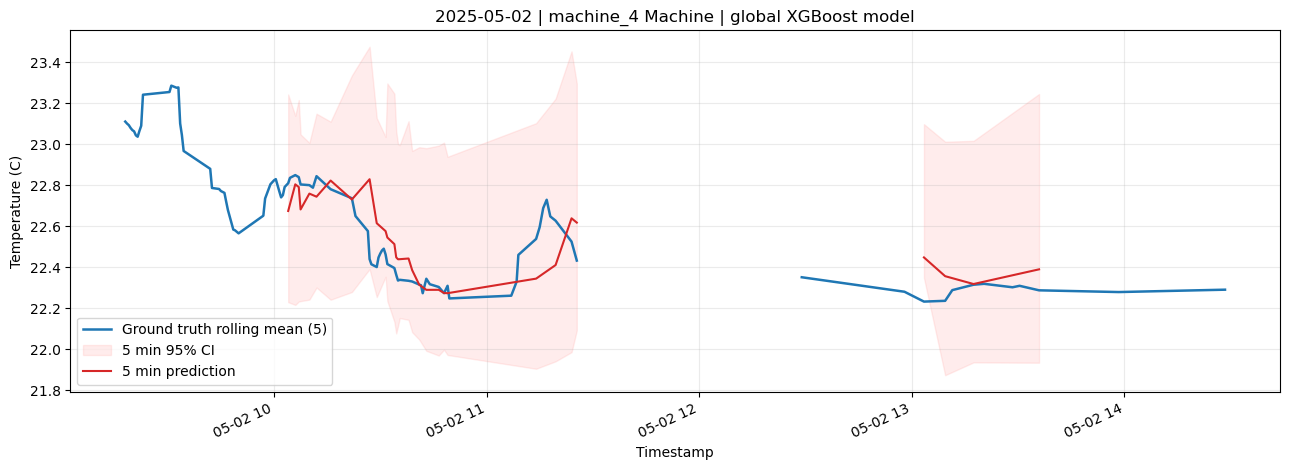

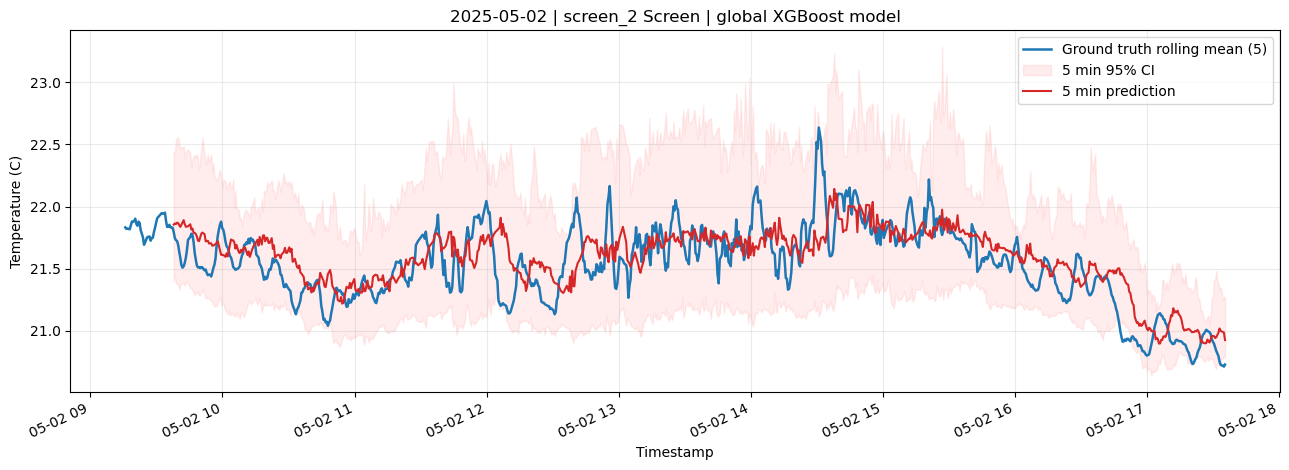

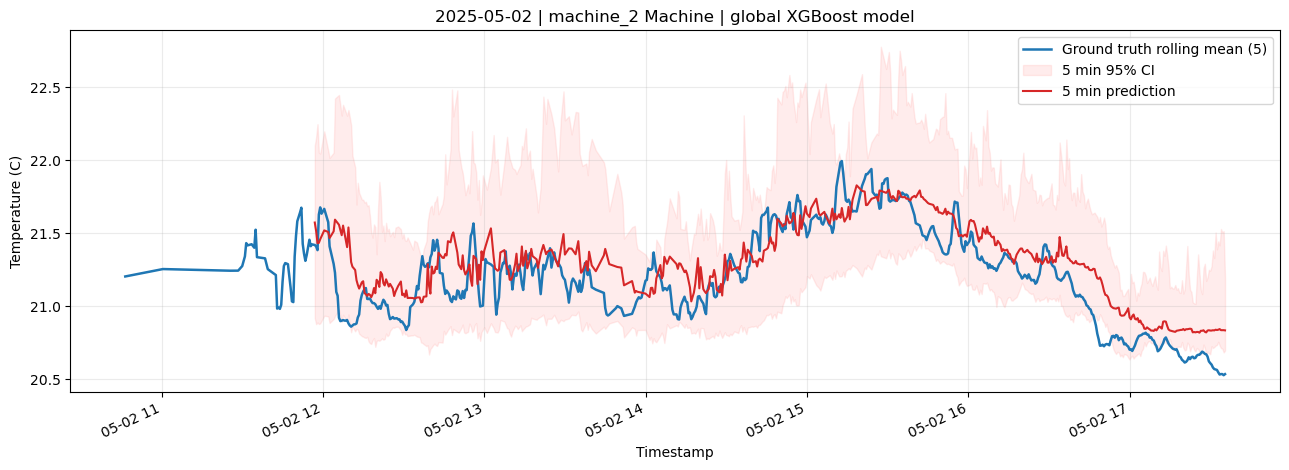

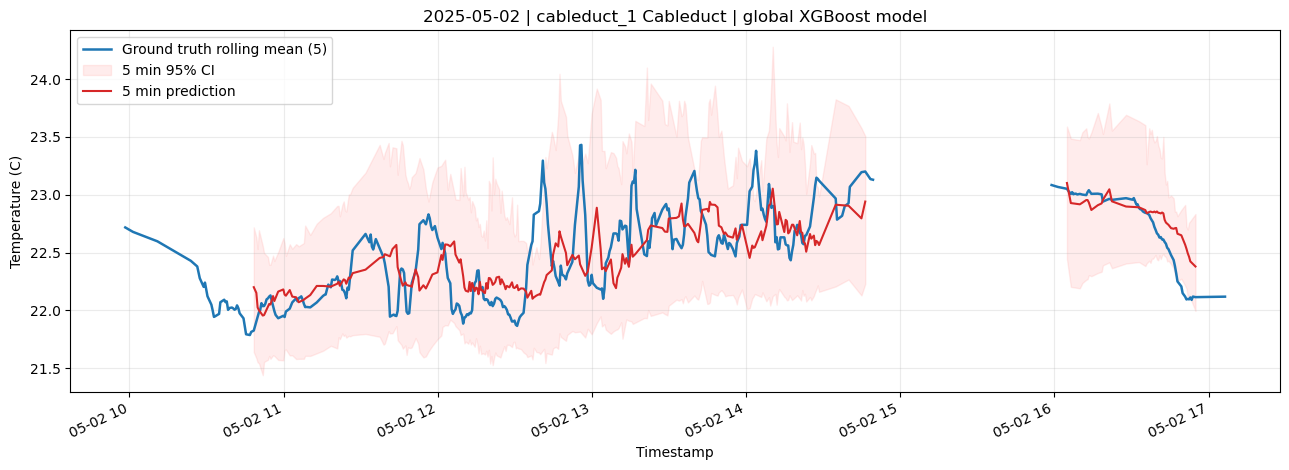

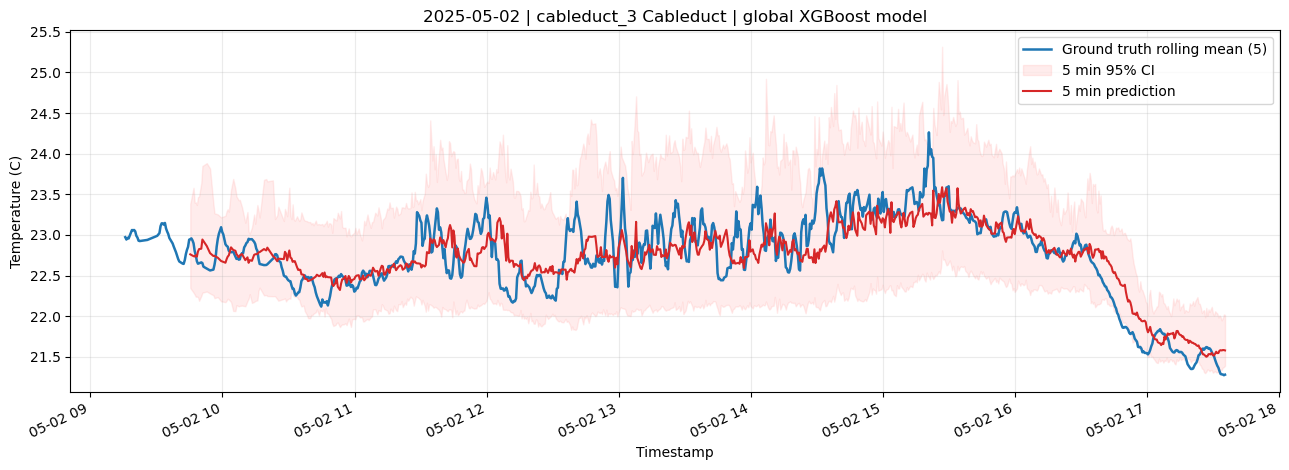

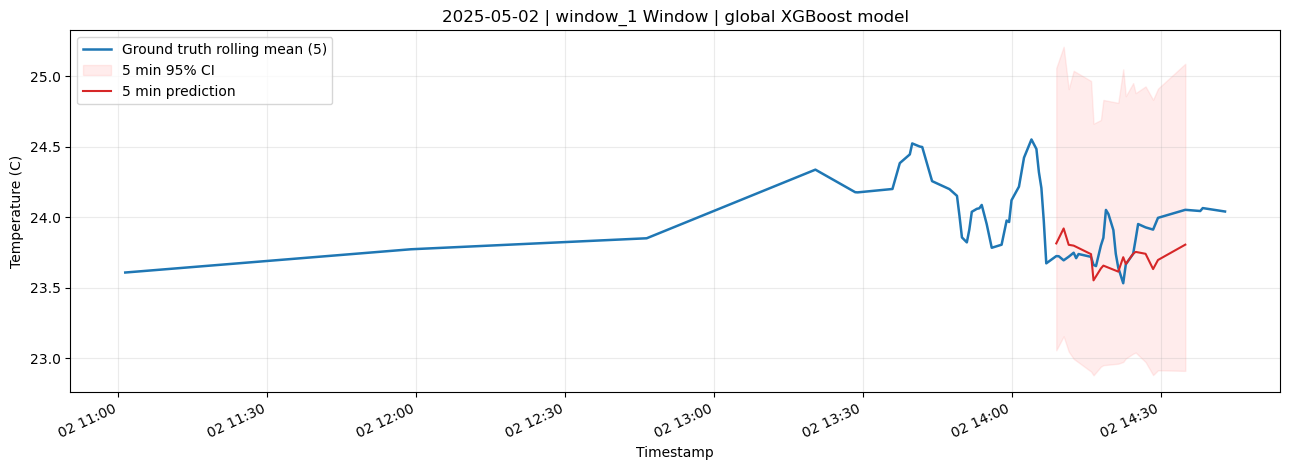

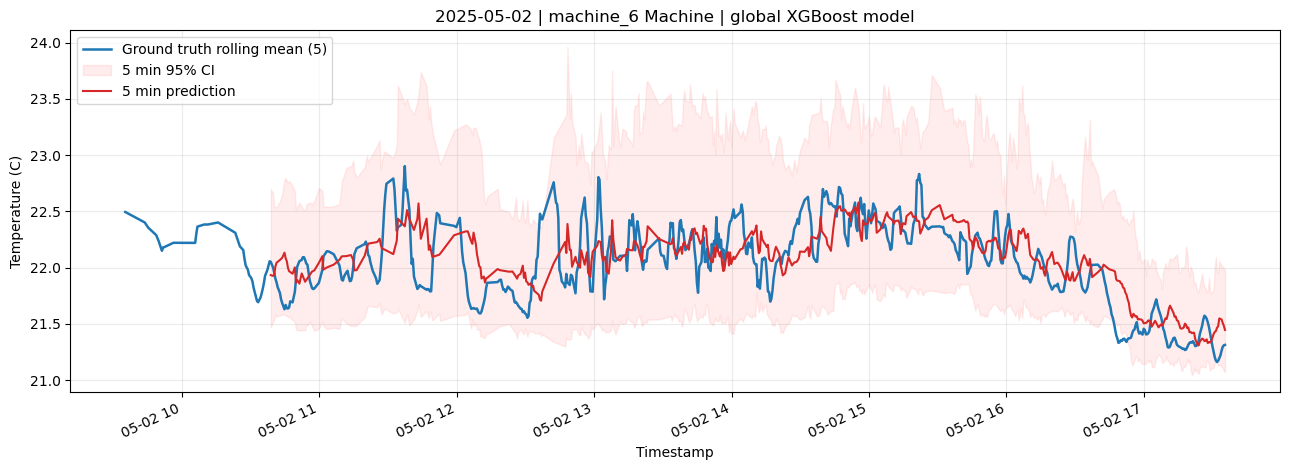

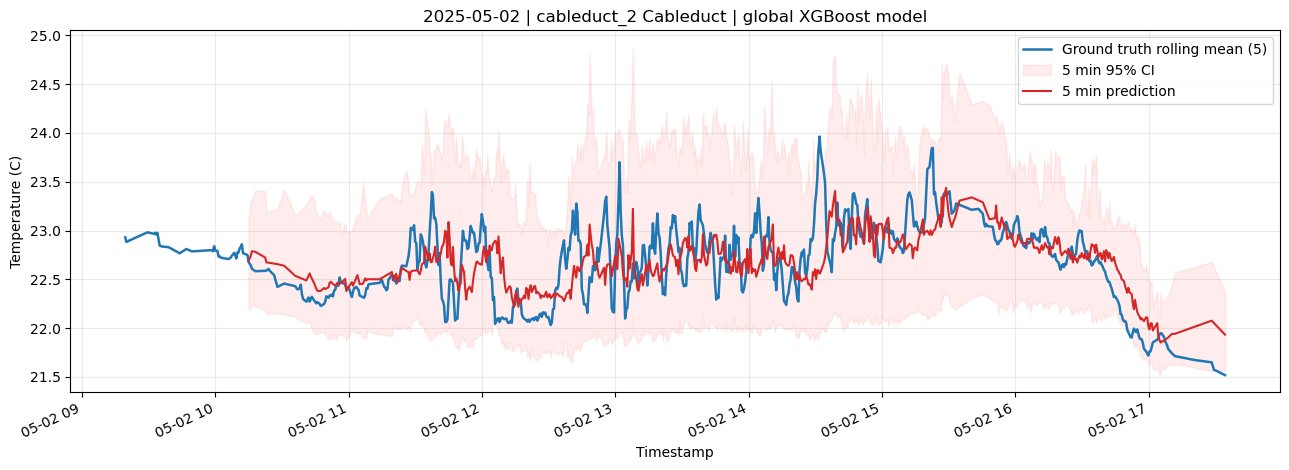

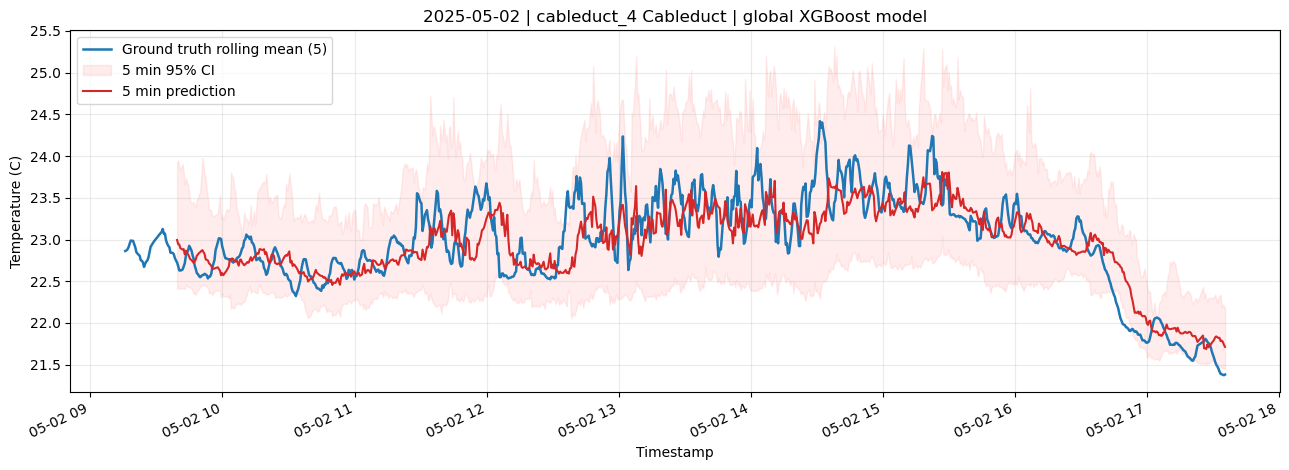

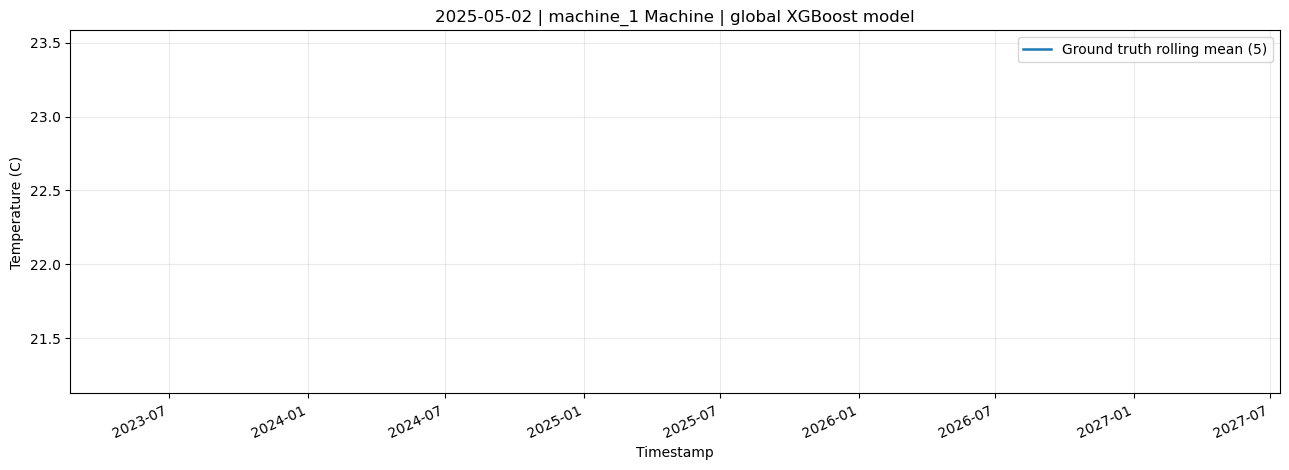

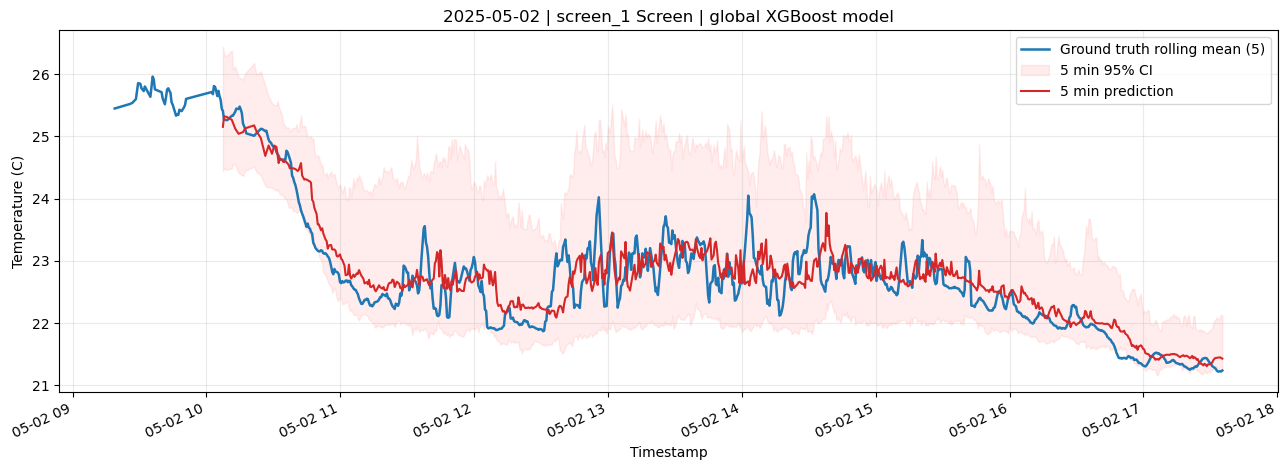

In [8]:
pred = result['predictions'].query("split == 'test'").copy()
pred['timestamp_dt'] = pd.to_datetime(pred['timestamp_dt'])
pred['target_timestamp'] = pd.to_datetime(pred['target_timestamp'])
pred['ci_width'] = pred['ci_upper'] - pred['ci_lower']

PLOT_OBJECT_IDS = []
N_OBJECTS_TO_PLOT = 15  # Set None to plot all objects.
MAX_POINTS_PER_OBJECT_DAY = None
MAX_LINE_GAP_MINUTES = 60.0
GT_SMOOTH_WINDOW = 5  # Visual-only rolling mean window for ground truth.


def add_plot_segments(df, time_col, max_gap_minutes=60.0):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    segment = gap.gt(max_gap_minutes).fillna(False).cumsum()
    return df.assign(_plot_segment=segment)


def smooth_ground_truth(df, value_col='ground_truth', window=5):
    df = df.sort_values('timestamp_dt').copy()
    if window is None or window <= 1 or df.empty:
        df['ground_truth_plot'] = df[value_col]
    else:
        df['ground_truth_plot'] = (
            df[value_col]
            .rolling(window=window, center=True, min_periods=1)
            .mean()
        )
    return df


def downsample_df(df, max_points):
    if max_points is None or len(df) <= max_points:
        return df
    keep_idx = np.linspace(0, len(df) - 1, max_points).astype(int)
    return df.iloc[keep_idx].copy()


timeline_gt = pd.read_csv(config.OBJECT_TIMELINE_CSV)
timeline_gt = timeline_gt[timeline_gt['people_or_machine'] == PEOPLE_OR_MACHINE].copy()
timeline_gt['timestamp_dt'] = pd.to_datetime(timeline_gt['timestamp'])
timeline_gt[TEMPERATURE_COLUMN] = pd.to_numeric(timeline_gt[TEMPERATURE_COLUMN], errors='coerce')
timeline_gt = timeline_gt.dropna(subset=['object_id', 'timestamp_dt', TEMPERATURE_COLUMN])
timeline_gt = (
    timeline_gt
    .groupby(['object_id', 'timestamp_dt'], as_index=False)
    .agg(
        canonical_label=('canonical_label', lambda s: s.mode().iloc[0] if not s.mode().empty else ''),
        ground_truth=(TEMPERATURE_COLUMN, 'mean'),
    )
)
timeline_gt['target_date'] = timeline_gt['timestamp_dt'].dt.date

plot_pred = (
    pred
    .groupby(['object_id', 'canonical_label', 'requested_horizon_min', 'target_timestamp'], as_index=False)
    .agg(
        prediction=('prediction', 'median'),
        ci_lower=('ci_lower', 'median'),
        ci_upper=('ci_upper', 'median'),
        prediction_rows=('prediction', 'size'),
    )
)
plot_pred['target_date'] = plot_pred['target_timestamp'].dt.date
plot_pred['ci_width'] = plot_pred['ci_upper'] - plot_pred['ci_lower']

object_confidence = (
    plot_pred.groupby(['object_id', 'canonical_label'], as_index=False)
    .agg(rows=('prediction', 'size'), mean_ci_width=('ci_width', 'mean'))
    .sort_values('mean_ci_width')
)
display(object_confidence)

if PLOT_OBJECT_IDS:
    object_ids_to_plot = PLOT_OBJECT_IDS
else:
    object_ids_to_plot = object_confidence['object_id'].tolist()
    if N_OBJECTS_TO_PLOT is not None:
        object_ids_to_plot = object_ids_to_plot[:N_OBJECTS_TO_PLOT]

horizon_colors = {5.0: '#d62728'}
horizon_fill = {5.0: '#ff9896'}

print(f"GT plot rows from timeline: {len(timeline_gt):,}")
print(f"Prediction plot rows: {len(pred):,} -> {len(plot_pred):,} after target-time aggregation")

for target_date in sorted(plot_pred['target_date'].unique()):
    print(f'Target date: {target_date}')
    for object_id in object_ids_to_plot:
        object_pred_day = plot_pred[(plot_pred['object_id'] == object_id) & (plot_pred['target_date'] == target_date)].copy()
        object_gt_day = timeline_gt[(timeline_gt['object_id'] == object_id) & (timeline_gt['target_date'] == target_date)].copy()
        object_gt_day = smooth_ground_truth(object_gt_day, window=GT_SMOOTH_WINDOW)
        if object_pred_day.empty and object_gt_day.empty:
            continue
        if object_pred_day.empty:
            label = object_gt_day['canonical_label'].mode().iloc[0] if not object_gt_day['canonical_label'].mode().empty else ''
        else:
            label = object_pred_day['canonical_label'].mode().iloc[0] if not object_pred_day['canonical_label'].mode().empty else ''

        fig, ax = plt.subplots(figsize=(13, 4.8))

        gt_df = downsample_df(
            add_plot_segments(object_gt_day, 'timestamp_dt', MAX_LINE_GAP_MINUTES),
            MAX_POINTS_PER_OBJECT_DAY,
        )
        for segment_id, segment in gt_df.groupby('_plot_segment'):
            ax.plot(
                segment['timestamp_dt'],
                segment['ground_truth_plot'],
                color='#1f77b4',
                linewidth=1.8,
                label=f'Ground truth rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
            )

        for horizon_min in FORECAST_HORIZONS_MIN:
            part = object_pred_day[object_pred_day['requested_horizon_min'] == horizon_min].copy()
            if part.empty:
                continue
            part = downsample_df(
                add_plot_segments(part, 'target_timestamp', MAX_LINE_GAP_MINUTES),
                MAX_POINTS_PER_OBJECT_DAY,
            )
            first_segment = part['_plot_segment'].min()
            for segment_id, segment in part.groupby('_plot_segment'):
                ax.fill_between(
                    segment['target_timestamp'],
                    segment['ci_lower'],
                    segment['ci_upper'],
                    color=horizon_fill.get(float(horizon_min), 'orange'),
                    alpha=0.18,
                    label=f'{horizon_min:g} min 95% CI' if segment_id == first_segment else None,
                )
                ax.plot(
                    segment['target_timestamp'],
                    segment['prediction'],
                    color=horizon_colors.get(float(horizon_min), '#333333'),
                    linewidth=1.5,
                    label=f'{horizon_min:g} min prediction' if segment_id == first_segment else None,
                )

        ax.set_title(f'{target_date} | {object_id} {label} | global XGBoost model')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Temperature (C)')
        ax.grid(alpha=0.25)
        ax.legend(loc='best')
        fig.autofmt_xdate(rotation=25)
        fig.tight_layout()


## One Source Timestamp Forecast Point

This view shows one object at one source timestamp for the 5-minute forecast.


,object_id,timestamp_dt,target_timestamp,requested_horizon_min,source_temp,target_temp,prediction,ci_lower,ci_upper
48282,machine_3,2025-04-24 10:32:47,2025-04-24 10:37:48,5.0,22.269361,22.093212,22.40045,21.900488,23.096941


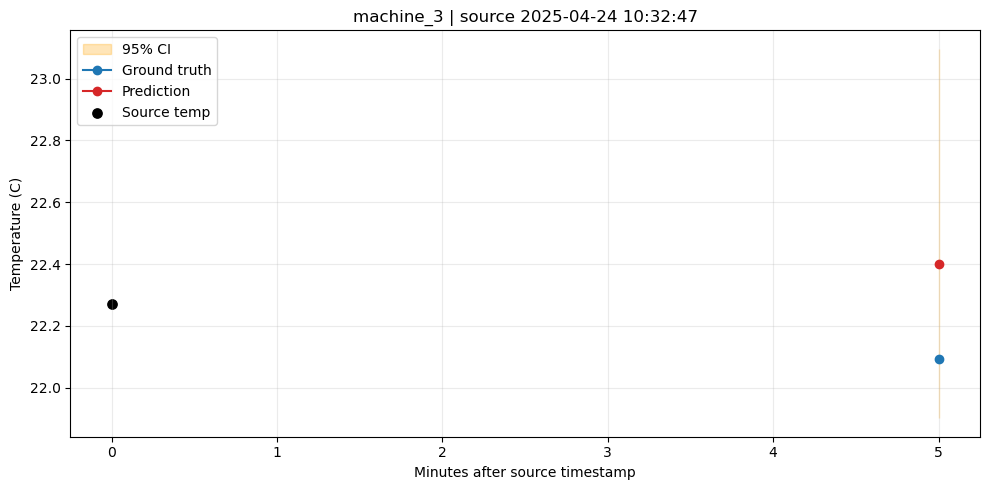

In [9]:
FORECAST_OBJECT_ID = None  # Example: 'cableduct_1'. None chooses the most confident object.
FORECAST_SOURCE_TIMESTAMP = None  # Example: '2025-05-06 10:00:00'. None chooses a source timestamp with many horizons.

if FORECAST_OBJECT_ID is None:
    FORECAST_OBJECT_ID = object_confidence.iloc[0]['object_id']

one_object = pred[pred['object_id'] == FORECAST_OBJECT_ID].copy()
if FORECAST_SOURCE_TIMESTAMP is None:
    source_counts = one_object.groupby('timestamp_dt').size().sort_values(ascending=False)
    FORECAST_SOURCE_TIMESTAMP = source_counts.index[0]
else:
    FORECAST_SOURCE_TIMESTAMP = pd.to_datetime(FORECAST_SOURCE_TIMESTAMP)

path = one_object[one_object['timestamp_dt'] == FORECAST_SOURCE_TIMESTAMP].sort_values('requested_horizon_min')
if path.empty:
    raise ValueError('No forecast path found for the selected object and source timestamp.')

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(path['requested_horizon_min'], path['ci_lower'], path['ci_upper'], color='orange', alpha=0.28, label='95% CI')
ax.plot(path['requested_horizon_min'], path['target_temp'], color='#1f77b4', marker='o', label='Ground truth')
ax.plot(path['requested_horizon_min'], path['prediction'], color='#d62728', marker='o', label='Prediction')
ax.scatter([0], [path['source_temp'].iloc[0]], color='black', s=45, label='Source temp')
ax.set_title(f'{FORECAST_OBJECT_ID} | source {pd.to_datetime(FORECAST_SOURCE_TIMESTAMP)}')
ax.set_xlabel('Minutes after source timestamp')
ax.set_ylabel('Temperature (C)')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()

path[['object_id', 'timestamp_dt', 'target_timestamp', 'requested_horizon_min', 'source_temp', 'target_temp', 'prediction', 'ci_lower', 'ci_upper']]


## Outputs


In [10]:
{
    'prediction_csv': str(forecast_args.prediction_csv),
    'metrics_csv': str(forecast_args.metrics_csv),
    'feature_importance_csv': str(forecast_args.feature_importance_csv),
    'learning_curve_png': str(forecast_args.learning_curve_png),
    'model_dir': str(forecast_args.output_dir),
}


{'prediction_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/multihorizon/xgboost_5min_predictions.csv',
 'metrics_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/multihorizon/xgboost_5min_metrics.csv',
 'feature_importance_csv': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/multihorizon/xgboost_5min_feature_importance.csv',
 'learning_curve_png': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/multihorizon/xgboost_5min_learning_curve.png',
 'model_dir': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/xgboost/multihorizon'}